# Real-Time Early Warning Signal for Core PCE Inflation (standalone)

Self-contained build of the early-warning machinery: the **pipeline pressure composite**
(Exhibit 13c), the **real-time warning score** (Section 4c, Exhibit 13e), and the
**confirmation score / agreement reading** (Section 4d, Exhibit 13f).

Local dependencies: `core_lines.xlsx` (117 core PCE component codes) and the
`data_cache/` parquet cache; API keys are inline. All data comes from the BEA and FRED APIs; with a
populated cache a run makes zero API calls (`REFRESH = True` re-pulls everything).

Method summary: 25 core PCE components are selected by standardized RMSE against core at
leads of 3-12 months around the persistent-inflation episodes, after screening out imputed
series and the most oil-sensitive components. Four subscores — pipeline pressure, breadth of
accelerating components, basket acceleration, basket-vs-core gap — are each converted to an
expanding percentile using only prior history (120-month minimum), averaged, and gated:
a warning fires at a score of 75+ for two consecutive months with at least two hot subscores.
The confirmation variant re-selects the basket on the 1970s episodes alone, so agreement
between the two scores cannot come from components chosen for their 2021 behavior.

In [1]:
# ---------------- configuration ----------------
from pathlib import Path
import time

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

_DEFAULT = Path(r"C:\Users\abour\OneDrive\Economic Research\Inflation Risk")
PROJ = Path.cwd() if (Path.cwd() / "core_lines.xlsx").exists() else _DEFAULT
CACHE = PROJ / "data_cache"
CACHE.mkdir(exist_ok=True)
FIG_DIR = PROJ / "figure"
FIG_DIR.mkdir(exist_ok=True)

REFRESH = False          # True -> re-pull everything from the APIs (~2 min, BEA throttled)
START_YEAR = 1959        # first year of BEA monthly underlying detail
CHUNK_YEARS = 5          # years per BEA API call (stays under BEA volume caps)
LEADS = range(3, 13)     # candidate leads (months) at which a component may front-run core
TOP_N = 25               # components per early-warning basket

OIL_PENALTY_Q = 0.85     # exclude components above this oil pass-through R2 percentile
OIL_LAGS = range(0, 7)   # WTI monthly log-diff lags in the pass-through regression
IMPUTED_EXCLUDE = [      # imputed / nonmarket series screened from the candidate pool
    "Casino gambling", "Lotteries", "Pari-mutuel net receipts",
    "Financial services furnished without payment",
    "Food furnished to employees", "Standard clothing issued to military",
]

PIPE_IDS = ["WPSID61", "WPSID62", "CUMFNS", "AWHMAN", "IREXPET", "FRBATLWGTUMHWGO"]
PIPE_MIN_MEMBERS = 4     # pipeline composite requires >= this many members in a month
BREADTH_ACCEL_PP = 0.5   # a component is "accelerating" if YoY is up >= this vs 6m earlier

REALTIME_MIN_HISTORY = 120    # months of prior history before an expanding percentile is reported
WARNING_SCORE_THRESHOLD = 75
WARNING_SUBSCORE_THRESHOLD = 70
WARNING_RUN = 2               # consecutive hot months required to fire

ERA1_WINDOWS = [("1972-06", "1976-06"), ("1977-01", "1981-06")]   # 1970s selection episodes
ERA2_WINDOWS = [("2020-06", "2023-06")]                           # 2021-22 selection episode

NAVY, LTBLUE = "#0f2b5b", "#7fb2d9"

BEA_KEY = "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"
FRED_KEY = "51f3ac7bc8b65cb6bb2589fc570292be"

core_lines = pd.read_excel(PROJ / "core_lines.xlsx")
PRICE_CODES = core_lines["Code"].tolist()
NOM_CODES = [c[:-1] + "C" for c in PRICE_CODES]   # nominal code = price code with G -> C
CODE2DESC = {c: d.strip() for c, d in zip(core_lines["Code"], core_lines["Description"])}
assert len(PRICE_CODES) == 117, "expected 117 core PCE components"
print(f"{len(PRICE_CODES)} core PCE components loaded from core_lines.xlsx")

117 core PCE components loaded from core_lines.xlsx


In [2]:
# ---------------- data (BEA + FRED, parquet-cached) ----------------
HTTP_REQUESTS = {"count": 0}


def _get(url, params):
    HTTP_REQUESTS["count"] += 1
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    return r.json()


def cache_io(name, fetch_fn):
    pq = CACHE / f"{name}.parquet"
    if not REFRESH and pq.exists():
        return pd.read_parquet(pq)
    df = fetch_fn()
    df.to_parquet(pq)
    return df


def bea_table_wide(table, key):
    """Pull a monthly BEA NIUnderlyingDetail table across all years, wide format."""
    this_year = pd.Timestamp.today().year
    frames = []
    for y0 in range(START_YEAR, this_year + 1, CHUNK_YEARS):
        years = ",".join(str(y) for y in range(y0, min(y0 + CHUNK_YEARS, this_year + 1)))
        js = _get("https://apps.bea.gov/api/data/", {
            "UserID": key, "method": "GetData", "datasetname": "NIUnderlyingDetail",
            "TableName": table, "Frequency": "M", "Year": years, "ResultFormat": "json"})
        res = js["BEAAPI"]["Results"]
        if "Error" in res:
            raise RuntimeError(f"BEA error for {table} {years}: {res['Error']}")
        frames.append(pd.DataFrame(res["Data"])[["SeriesCode", "TimePeriod", "DataValue"]])
        time.sleep(1)
    long = pd.concat(frames, ignore_index=True)
    long["DataValue"] = pd.to_numeric(long["DataValue"].str.replace(",", ""), errors="coerce")
    long["date"] = pd.to_datetime(long["TimePeriod"], format="%YM%m")
    long = long.drop_duplicates(["SeriesCode", "date"], keep="last")
    return long.pivot(index="date", columns="SeriesCode", values="DataValue").sort_index()


def fred_series(sid, key):
    js = _get("https://api.stlouisfed.org/fred/series/observations",
              {"series_id": sid, "api_key": key, "file_type": "json"})
    obs = pd.DataFrame(js["observations"])
    s = pd.to_numeric(obs["value"], errors="coerce")   # "." -> NaN
    s.index = pd.to_datetime(obs["date"])
    s.name = sid
    return s


prices_all = cache_io("U20404", lambda: bea_table_wide("U20404", BEA_KEY))
nominal_all = cache_io("U20405", lambda: bea_table_wide("U20405", BEA_KEY))
_core_df = cache_io("FRED_CORE", lambda: pd.concat(
    [fred_series(sid, FRED_KEY) for sid in ("PCEPILFE", "AHETPI")], axis=1))
wti = cache_io("WTI", lambda: fred_series("WTISPLC", FRED_KEY).to_frame())["WTISPLC"].dropna()
wti.index = wti.index.to_period("M").to_timestamp()
_pipe_df = cache_io("FRED_PIPE", lambda: pd.concat(
    [fred_series(sid, FRED_KEY) for sid in PIPE_IDS], axis=1))
pfred = {c: _pipe_df[c].dropna() for c in _pipe_df.columns}

missing = ([c for c in PRICE_CODES if c not in prices_all.columns]
           + [c for c in NOM_CODES if c not in nominal_all.columns])
assert not missing, f"missing BEA codes: {missing}"

LAST_MONTH = _core_df["PCEPILFE"].dropna().index.max()   # last month with official core PCE
prices = prices_all[PRICE_CODES].loc[:LAST_MONTH]
nominal = nominal_all[NOM_CODES].rename(columns=dict(zip(NOM_CODES, PRICE_CODES))).loc[:LAST_MONTH]
print(f"prices {prices.shape}  {prices.index.min():%Y-%m} -> {prices.index.max():%Y-%m}")
print(f"HTTP requests this run: {HTTP_REQUESTS['count']}")

prices (809, 117)  1959-01 -> 2026-05
HTTP requests this run: 0


In [3]:
# ---------------- component inflation, weights, validity check ----------------
comp_yoy = prices.pct_change(12) * 100
core_yoy = (_core_df["PCEPILFE"].dropna().pct_change(12) * 100).dropna()

_shares = nominal.div(nominal.sum(axis=1), axis=0)
W = _shares.shift(1).rolling(12, min_periods=6).mean()
W = W.div(W.sum(axis=1), axis=0)   # lagged 12m-trailing nominal shares

# Tornqvist reconstruction must track official core PCE (guards code mapping and weights)
_mom = np.log(prices).diff()
_wa = W.where(_mom.notna())
_wa = _wa.div(_wa.sum(axis=1), axis=0)
_recon = ((_wa * _mom).sum(axis=1, min_count=50).rolling(12).sum() * 100).dropna()
_common = _recon.index.intersection(core_yoy.index)
_common = _common[_common >= "1961-01-01"]
RECON_CORR = _recon.loc[_common].corr(core_yoy.loc[_common])
assert RECON_CORR > 0.98, f"reconstruction corr {RECON_CORR:.4f} - check weights/code mapping"
print(f"Tornqvist reconstruction vs core PCE YoY: corr={RECON_CORR:.4f}")

Tornqvist reconstruction vs core PCE YoY: corr=0.9973


In [4]:
# ---------------- basket selection (standardized RMSE at leads 3-12m) ----------------

def episode_mask(index, windows):
    mask = pd.Series(False, index=index)
    for a, b in windows:
        mask.loc[a:b] = True
    return mask


def score_component(cy, core, mask, leads=LEADS, min_cov=0.9):
    """Best (lowest) z-scored RMSE between cy shifted forward h months and core."""
    dates = mask.index[mask]
    best = (np.nan, np.nan)
    for h in leads:
        x, y = cy.shift(h).reindex(dates), core.reindex(dates)
        ok = x.notna() & y.notna()
        if ok.sum() < min_cov * len(dates):
            continue
        xx, yy = x[ok], y[ok]
        if xx.std() == 0 or yy.std() == 0:
            continue
        xx, yy = (xx - xx.mean()) / xx.std(), (yy - yy.mean()) / yy.std()
        rmse = float(np.sqrt(((xx - yy) ** 2).mean()))
        if not (best[0] <= rmse):
            best = (rmse, h)
    return best


mask1 = episode_mask(comp_yoy.index, ERA1_WINDOWS)
mask2 = episode_mask(comp_yoy.index, ERA2_WINDOWS)
_rmse, _lead = score_component(core_yoy.shift(-6), core_yoy, mask1)
assert _lead == 6, f"shift-direction bug: recovered lead {_lead}"

scores = pd.DataFrame(
    {code_: {"std1": score_component(comp_yoy[code_], core_yoy, mask1)[0],
             "std2": score_component(comp_yoy[code_], core_yoy, mask2)[0]}
     for code_ in PRICE_CODES}).T.dropna()

# Screen 1: imputed / nonmarket series. Screen 2: oil pass-through R2 (dln price on WTI lags).
IMPUTED = [c for c in scores.index
           if any(k.lower() in CODE2DESC[c].lower() for k in IMPUTED_EXCLUDE)]
pool = scores.drop(index=IMPUTED)
_dlp, _dlw = np.log(prices).diff(), np.log(wti).diff()
_X_all = pd.concat({h: _dlw.shift(h) for h in OIL_LAGS}, axis=1)
_oil = {}
for code_ in pool.index:
    y = _dlp[code_].dropna()
    Xc = _X_all.reindex(y.index).dropna()
    y2 = y.reindex(Xc.index)
    if len(y2) < 120:
        continue
    X = np.column_stack([np.ones(len(Xc)), Xc.values])
    beta, *_ = np.linalg.lstsq(X, y2.values, rcond=None)
    _oil[code_] = 1 - (y2.values - X @ beta).var() / y2.values.var()
OIL_R2 = pd.Series(_oil)
OIL_EXCLUDED = OIL_R2[OIL_R2 > OIL_R2.quantile(OIL_PENALTY_Q)]
pool = pool.drop(index=OIL_EXCLUDED.index)
print(f"candidate pool: {len(pool)} components "
      f"({len(IMPUTED)} imputed and {len(OIL_EXCLUDED)} oil-sensitive screened out)")


def select(df, cols, top_n=TOP_N, gate=0.5):
    """Top-N by mean percentile rank among components in the top half on every column."""
    ranks = pd.concat({c: df[c].rank(pct=True) for c in cols}, axis=1)
    ok = ranks[(ranks <= gate).all(axis=1)].index
    if len(ok) < top_n:
        print(f"only {len(ok)} pass the top-{gate:.0%} gate on {list(cols)}; relaxing to 60%")
        ok = ranks[(ranks <= 0.6).all(axis=1)].index
    return ranks.mean(axis=1).loc[ok].nsmallest(top_n).index.tolist()


def weighted_yoy(comp_yoy, W, cols):
    cy = comp_yoy[cols]
    w = W[cols].where(cy.notna())
    w = w.div(w.sum(axis=1), axis=0)
    return (w * cy).sum(axis=1, min_count=max(3, len(cols) // 2))


selected = select(pool, ["std1", "std2"])   # main basket: both eras
oos_selected = select(pool, ["std1"])       # confirmation basket: 1970s ranks only
ew = weighted_yoy(comp_yoy, W, selected).dropna()
ew_oos = weighted_yoy(comp_yoy, W, oos_selected).dropna()
print(f"main basket {len(selected)}, confirmation basket {len(oos_selected)}, "
      f"overlap {len(set(selected) & set(oos_selected))}")
print("\nmain basket:")
for c in selected:
    print(f"  {CODE2DESC[c]}")

candidate pool: 92 components (6 imputed and 17 oil-sensitive screened out)
main basket 25, confirmation basket 25, overlap 12

main basket:
  Purchased meals and beverages (102)
  Furniture
  Tires
  Carpets and other floor coverings
  Clothing and footwear services
  Other household services
  Other motor vehicle services (61)
  Games, toys, and hobbies
  Religious organizations' services to households
  Flowers, seeds, and potted plants
  New light trucks
  Shoes and other footwear
  Repair of furniture, furnishings, and floor coverings
  Repair and rental of audio-visual, photographic, and information processing equipment
  New autos
  Pets and related products
  Veterinary and other services for pets
  Tools, hardware, and supplies
  Physician services (44)
  Moving, storage, and freight services
  Outdoor equipment and supplies
  Cable, satellite, and other live television services
  Luggage and similar personal items (part of 119)
  Clocks, lamps, lighting fixtures, and other ho

## Pipeline pressure composite

Mean full-sample z-score of upstream cost and pressure series (PPI intermediate demand
processed/unprocessed, manufacturing capacity utilization, factory weekly hours, average
hourly earnings, import prices ex petroleum 1985+, Atlanta Fed wage tracker 1997+),
3-month average, at least four members required. Input costs move before consumer prices,
so this composite escapes the mechanical co-movement that limits any basket built from
core's own components. The real-side members (utilization, hours) kept it quiet through
the 2004-07 and 2010-11 commodity booms.

In [5]:
# ---------------- pipeline composite, breadth, shared helpers ----------------

def _yoy12(s):
    return s.dropna().pct_change(12) * 100


PIPE_MEMBERS = {
    "PPI intermediate, processed":   _yoy12(pfred["WPSID61"]),
    "PPI intermediate, unprocessed": _yoy12(pfred["WPSID62"]),
    "Capacity utilization (mfg)":    pfred["CUMFNS"],
    "Factory weekly hours":          pfred["AWHMAN"],
    "Avg hourly earnings":           _yoy12(_core_df["AHETPI"].dropna()),
    "Import prices ex petroleum":    _yoy12(pfred["IREXPET"]),
    "Atlanta Fed wage tracker":      pfred["FRBATLWGTUMHWGO"],
}
_pidx = pd.date_range("1948-01-01", LAST_MONTH, freq="MS")
_PZraw = pd.DataFrame(PIPE_MEMBERS, index=_pidx)
_PZ = (_PZraw - _PZraw.mean()) / _PZraw.std()
pipe = (_PZ.mean(axis=1).where(_PZ.notna().sum(axis=1) >= PIPE_MIN_MEMBERS)
        .rolling(3).mean().dropna())
print(f"pipeline composite: {pipe.index.min():%Y-%m} -> {pipe.index.max():%Y-%m}, "
      f"current {pipe.iloc[-1]:+.2f}sd")

# Weighted share of components accelerating >= 0.5pp vs 6 months earlier (3-month average)
_wb = W[PRICE_CODES].where(comp_yoy[PRICE_CODES].notna())
_wb = _wb.div(_wb.sum(axis=1), axis=0)
_accel = comp_yoy[PRICE_CODES] - comp_yoy[PRICE_CODES].shift(6)
breadth_accel = (_wb[_accel > BREADTH_ACCEL_PP].sum(axis=1, min_count=1) * 100).rolling(3).mean()


def onset_thresh(s, w_, t):
    """First month within the window that s exceeds threshold t."""
    ss = s.loc[w_[0]:w_[1]]
    hit = ss[ss > t]
    return hit.index.min() if len(hit) else pd.NaT


_d = lambda x: f"{x:%Y-%m}" if pd.notna(x) else "never"
# "tame" = core stays below 2.75% over the following 12 months (false-alarm test)
_tame = core_yoy.rolling(12).max().shift(-12) < 2.75

pipeline composite: 1948-06 -> 2026-05, current +0.29sd


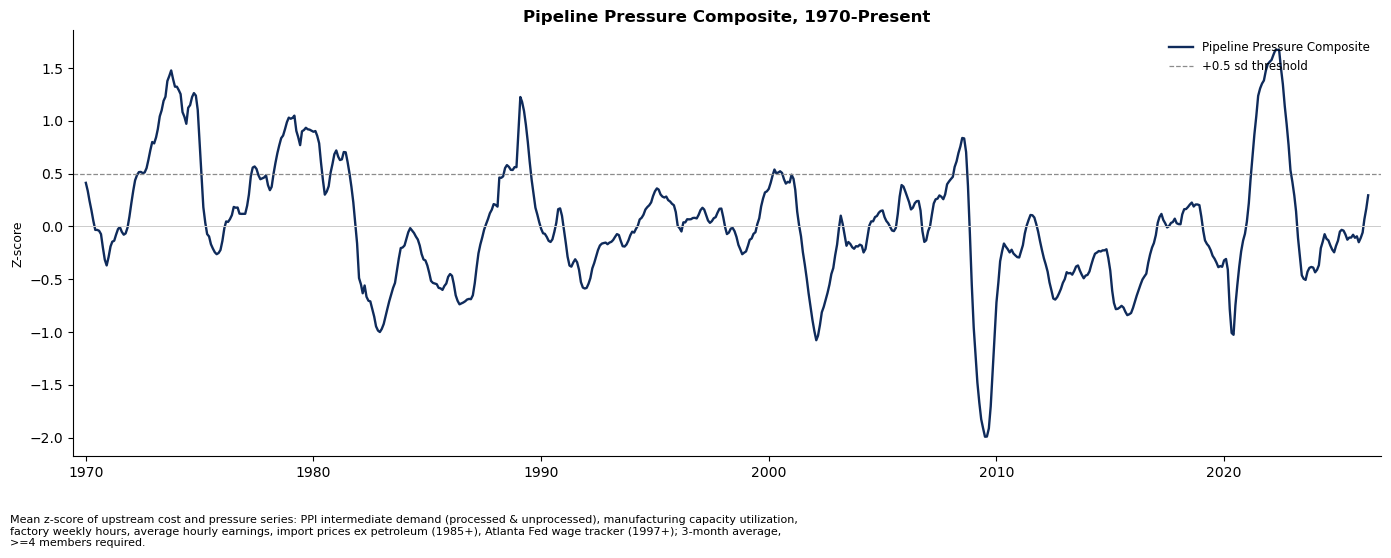

In [6]:
# ---------------- Exhibit 13c: pipeline pressure composite, 1970-present ----------------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pipe.loc["1970-01":], color=NAVY, lw=1.7)
ax.axhline(0.5, color="0.55", lw=0.9, ls="--")
ax.axhline(0, color="0.8", lw=0.7)
ax.set_title("Pipeline Pressure Composite, 1970-Present", fontsize=12, fontweight="bold")
ax.set_ylabel("Z-score", fontsize=9)
ax.margins(x=0.01)
ax.legend([plt.Line2D([], [], color=NAVY, lw=1.7),
           plt.Line2D([], [], color="0.55", lw=0.9, ls="--")],
          ["Pipeline Pressure Composite", "+0.5 sd threshold"],
          loc="upper right", fontsize=8.5, frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.text(0.01, -0.04,
         "Mean z-score of upstream cost and pressure series: PPI intermediate demand (processed & "
         "unprocessed), manufacturing capacity utilization,\nfactory weekly hours, average hourly "
         "earnings, import prices ex petroleum (1985+), Atlanta Fed wage tracker (1997+); "
         "3-month average,\n>=4 members required.",
         fontsize=8, va="top")
fig.tight_layout()
fig.savefig(FIG_DIR / "exhibit13c_pipeline_full_history.png", dpi=200, bbox_inches="tight")
plt.show()

## Section 4c — Real-Time Early Warning Signal

Each subscore is converted to an expanding percentile using only prior history, with at
least 120 months required before a percentile is reported — a 1978 analyst could have
computed the same score. The score combines four signals:

- pipeline pressure from upstream cost and labor-market series;
- breadth of detailed core PCE components accelerating versus six months earlier;
- acceleration in the early-warning basket;
- the gap between the early-warning basket and core PCE six months earlier.

A warning fires when the composite score is at least 75 for two consecutive months and at
least two subscores are above 70. Caveats: the data are current-vintage (revised), the
main basket's selection saw all three episodes (Section 4d removes that look-ahead), and
the 75/70/2 thresholds are round in-sample cuts rather than fitted parameters.

In [7]:
# ---------------- Section 4c: real-time early warning score ----------------

def expanding_percentile(s, min_history=REALTIME_MIN_HISTORY):
    """Prior-history percentile of s_t using only observations available before t."""
    s = s.dropna().sort_index()
    out = pd.Series(np.nan, index=s.index, dtype=float)
    hist = []
    for dt, val in s.items():
        if len(hist) >= min_history:
            h = np.asarray(hist, dtype=float)
            out.loc[dt] = 100.0 * (h <= val).mean()
        hist.append(float(val))
    return out


# Pipeline: percentile each upstream member on its own prior history, then average members.
_pipeline_member_scores = _PZraw.apply(expanding_percentile)
pipeline_pressure_score = (_pipeline_member_scores.mean(axis=1)
                           .where(_pipeline_member_scores.notna().sum(axis=1) >= PIPE_MIN_MEMBERS)
                           .rolling(3, min_periods=2).mean())

breadth_accel_score = expanding_percentile(breadth_accel)
ew_accel = (ew - ew.shift(6)).rolling(3, min_periods=2).mean()
ew_accel_score = expanding_percentile(ew_accel)
ew_gap = (ew - core_yoy.shift(6).reindex(ew.index)).rolling(3, min_periods=2).mean()
ew_gap_score = expanding_percentile(ew_gap)

warning_subscores = pd.concat({
    "Pipeline pressure": pipeline_pressure_score,
    "Component acceleration breadth": breadth_accel_score,
    "EW basket acceleration": ew_accel_score,
    "EW basket vs core gap": ew_gap_score,
}, axis=1).loc[:LAST_MONTH]
warning_score = (warning_subscores.mean(axis=1)
                 .where(warning_subscores.notna().sum(axis=1) >= 2))

_warning_hot = ((warning_score >= WARNING_SCORE_THRESHOLD)
                & ((warning_subscores >= WARNING_SUBSCORE_THRESHOLD).sum(axis=1) >= 2))
warning_signal = _warning_hot.copy()
for k in range(1, WARNING_RUN):
    warning_signal = warning_signal & _warning_hot.shift(k).eq(True)
warning_signal = warning_signal.fillna(False)

# Baseline: core PCE momentum alone under the same real-time percentile rule.
core_momentum = (core_yoy - core_yoy.shift(6)).rolling(3, min_periods=2).mean()
core_momentum_score = expanding_percentile(core_momentum)
core_momentum_hot = core_momentum_score >= WARNING_SCORE_THRESHOLD
core_momentum_signal = (core_momentum_hot & core_momentum_hot.shift(1).eq(True)).fillna(False)

print("latest warning subscores:")
print(warning_subscores.dropna(how="all").tail(1).round(1).T)
print(f"latest warning score: {warning_score.dropna().iloc[-1]:.1f}; "
      f"signal active: {bool(warning_signal.reindex(warning_score.index).iloc[-1])}")

latest warning subscores:
                                2026-05-01
Pipeline pressure                     63.1
Component acceleration breadth        54.4
EW basket acceleration                83.4
EW basket vs core gap                 62.4
latest warning score: 65.8; signal active: False


### Warning-Signal Validation

When the warning first fires around the main persistent-inflation episodes, plus behavior
in false-alarm check windows. Positive lead = the warning fired before core's threshold
date. The baseline applies the same rule to core PCE momentum alone; the warning is judged
better if it keeps positive leads while producing far fewer false alarms.

In [8]:
# ---------------- Section 4c: validation ----------------

def first_true(s, window):
    ss = s.loc[window[0]:window[1]]
    return ss[ss].index.min() if ss.any() else pd.NaT


def months_between(early, late):
    if pd.isna(early) or pd.isna(late):
        return np.nan
    return (late.to_period("M") - early.to_period("M")).n


VALIDATION_WINDOWS = [
    ("1973-75 acceleration", "1972-06", "1976-06", 4.0, True),
    ("1977-80 acceleration", "1977-01", "1981-06", 7.5, True),
    ("2021-22 acceleration", "2020-06", "2023-06", 3.0, True),
    ("2004-07 commodity boom", "2004-01", "2007-12", np.nan, False),
    ("2008-09 recession/shock", "2008-01", "2009-12", np.nan, False),
    ("2010-12 commodity rebound", "2010-01", "2012-12", np.nan, False),
    ("1985-2019 quiet audit", "1985-01", "2019-12", np.nan, False),
]

validation_rows = []
for label, a, b, threshold, target in VALIDATION_WINDOWS:
    search = (str(pd.Period(a, "M") - 12), b) if target else (a, b)
    core_date = onset_thresh(core_yoy, (a, b), threshold) if target else pd.NaT
    warn_date = first_true(warning_signal, search)
    base_date = first_true(core_momentum_signal, search)
    validation_rows.append({
        "window": label,
        "core threshold date": _d(core_date),
        "warning first date": _d(warn_date),
        "warning lead m": months_between(warn_date, core_date),
        "baseline first date": _d(base_date),
        "baseline lead m": months_between(base_date, core_date),
        "warning months": int(warning_signal.loc[a:b].sum()),
        "baseline months": int(core_momentum_signal.loc[a:b].sum()),
    })
warning_validation = pd.DataFrame(validation_rows).set_index("window")
display(warning_validation)

_EPS = ["1973-75 acceleration", "1977-80 acceleration", "2021-22 acceleration"]
main_episode_leads = warning_validation.loc[_EPS, "warning lead m"]
baseline_episode_leads = warning_validation.loc[_EPS, "baseline lead m"]
warning_false_alarms_8519 = int((warning_signal.loc["1985":"2019"]
                                 & _tame.reindex(warning_signal.loc["1985":"2019"].index)
                                 .fillna(False)).sum())
baseline_false_alarms_8519 = int((core_momentum_signal.loc["1985":"2019"]
                                  & _tame.reindex(core_momentum_signal.loc["1985":"2019"].index)
                                  .fillna(False)).sum())
print(f"1985-2019 false-alarm months: warning={warning_false_alarms_8519}, "
      f"core-momentum baseline={baseline_false_alarms_8519}")

,core threshold date,warning first date,warning lead m,baseline first date,baseline lead m,warning months,baseline months
window,,,,,,,
1973-75 acceleration,1973-08,1973-07,1.0,1973-07,1.0,21,22
1977-80 acceleration,1979-09,1978-09,12.0,1977-07,26.0,18,22
2021-22 acceleration,2021-04,2020-12,4.0,2020-12,4.0,20,19
2004-07 commodity boom,never,never,NaN,2004-03,NaN,0,8
2008-09 recession/shock,never,never,NaN,2009-12,NaN,0,1
2010-12 commodity rebound,never,2011-07,NaN,2010-01,NaN,4,13
1985-2019 quiet audit,never,2011-07,NaN,1987-10,NaN,4,53


1985-2019 false-alarm months: warning=4, core-momentum baseline=38


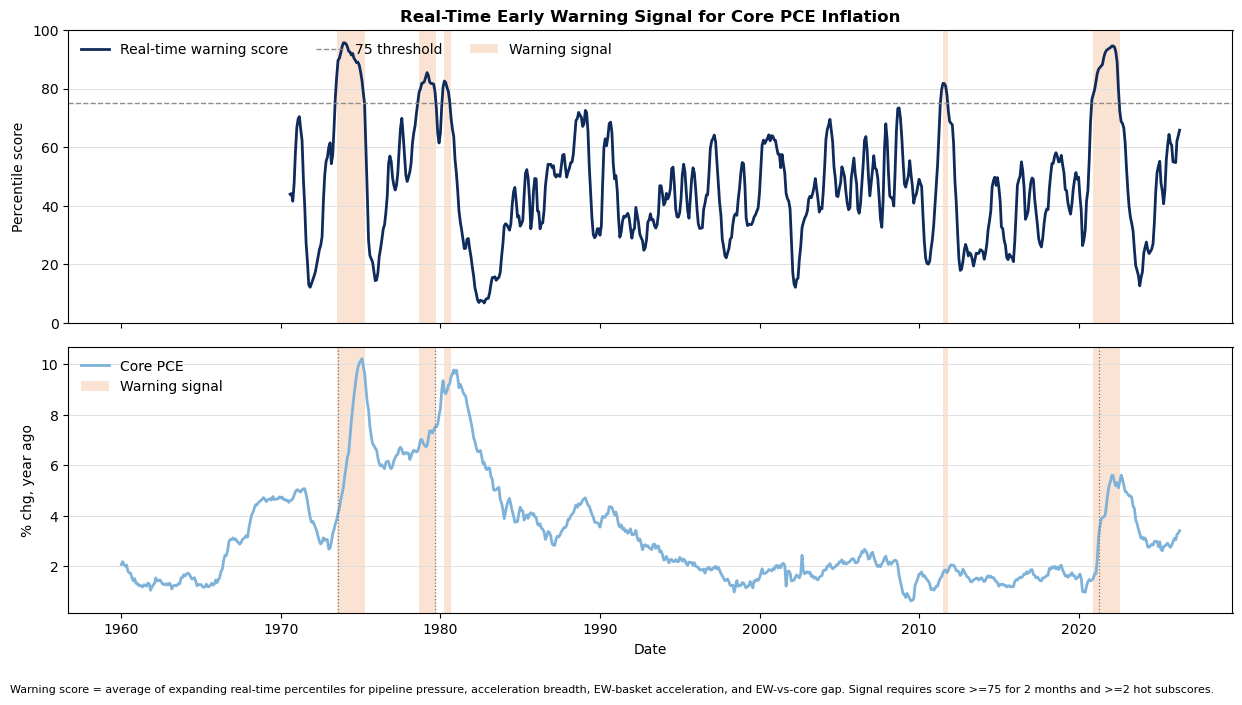

In [9]:
# ---------------- Exhibit 13e: real-time warning score ----------------

def shade_true_runs(ax, signal, color="#f4b183", alpha=0.35, label=None):
    groups = (signal != signal.shift()).cumsum()[signal]
    first = True
    for _, g in signal[signal].groupby(groups):
        ax.axvspan(g.index.min(), g.index.max() + pd.offsets.MonthBegin(1),
                   color=color, alpha=alpha, lw=0, label=label if first else None)
        first = False


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 7.2), sharex=True,
                               gridspec_kw={"height_ratios": [1.1, 1.0]})
ax1.plot(warning_score.index, warning_score, color=NAVY, lw=2.0, label="Real-time warning score")
ax1.axhline(WARNING_SCORE_THRESHOLD, color="0.55", lw=1.0, ls="--", label="75 threshold")
shade_true_runs(ax1, warning_signal, label="Warning signal")
ax1.set_ylim(0, 100)
ax1.set_ylabel("Percentile score")
ax1.set_title("Real-Time Early Warning Signal for Core PCE Inflation", fontweight="bold")
ax1.legend(loc="upper left", ncol=3, frameon=False)
ax1.grid(axis="y", color="0.88", lw=0.7)

ax2.plot(core_yoy.index, core_yoy, color=LTBLUE, lw=2.0, label="Core PCE")
shade_true_runs(ax2, warning_signal, label="Warning signal")
for _, a, b, threshold, target in VALIDATION_WINDOWS[:3]:
    cd = onset_thresh(core_yoy, (a, b), threshold)
    if pd.notna(cd):
        ax2.axvline(cd, color="0.45", lw=0.9, ls=":")
ax2.set_ylabel("% chg, year ago")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", frameon=False)
ax2.grid(axis="y", color="0.88", lw=0.7)

fig.text(0.01, 0.01,
         "Warning score = average of expanding real-time percentiles for pipeline pressure, "
         "acceleration breadth, EW-basket acceleration, and EW-vs-core gap. "
         "Signal requires score >=75 for 2 months and >=2 hot subscores.",
         fontsize=8)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
fig.savefig(FIG_DIR / "exhibit13e_warning_signal.png", dpi=200, bbox_inches="tight")
plt.show()

## Section 4d — Confirmation score (basket blind to the 2020s)

The **confirmation score** applies the identical rule to the basket selected on 1970s
episode ranks only, so none of its components were chosen with any knowledge of the 2020s.
It exists to guard against the one failure mode the main score cannot rule out: a hot
reading driven by components that earned their seat on 2021-era behavior.

Reading rule:
- **Both signals firing** — high-confidence warning (historically leads +1/+11/+2 months
  with zero tame-confirmed false alarms 1985-2019).
- **Main only** — discount; the 2011 false alarm was main-only.
- **Confirmation only** — rare (a few months in 1973 and the 1988 run-up, both ahead of
  real accelerations); treat as an early caution.

A wide gap between the two scores is itself information: the current reading then depends
on *which* components you trust, not on broad pressure.

In [10]:
# ---------------- Section 4d: confirmation score ----------------
confirmation_subscores = pd.concat({
    "Pipeline pressure": pipeline_pressure_score,          # selection-independent
    "Component acceleration breadth": breadth_accel_score,  # selection-independent
    "EW basket acceleration": expanding_percentile(
        (ew_oos - ew_oos.shift(6)).rolling(3, min_periods=2).mean()),
    "EW basket vs core gap": expanding_percentile(
        (ew_oos - core_yoy.shift(6).reindex(ew_oos.index)).rolling(3, min_periods=2).mean()),
}, axis=1).loc[:LAST_MONTH]
confirmation_score = (confirmation_subscores.mean(axis=1)
                      .where(confirmation_subscores.notna().sum(axis=1) >= 2))
_conf_hot = ((confirmation_score >= WARNING_SCORE_THRESHOLD)
             & ((confirmation_subscores >= WARNING_SUBSCORE_THRESHOLD).sum(axis=1) >= 2))
confirmation_signal = _conf_hot.copy()
for k in range(1, WARNING_RUN):
    confirmation_signal = confirmation_signal & _conf_hot.shift(k).eq(True)
confirmation_signal = confirmation_signal.fillna(False)

_joint_idx = warning_signal.index.union(confirmation_signal.index)
_main_sig = warning_signal.reindex(_joint_idx, fill_value=False)
_conf_sig = confirmation_signal.reindex(_joint_idx, fill_value=False)
high_confidence_signal = _main_sig & _conf_sig
main_only_signal = _main_sig & ~_conf_sig

hc_rows = []
for label, a, b, threshold, target in VALIDATION_WINDOWS:
    search = (str(pd.Period(a, "M") - 12), b) if target else (a, b)
    core_date = onset_thresh(core_yoy, (a, b), threshold) if target else pd.NaT
    conf_date = first_true(confirmation_signal, search)
    hc_date = first_true(high_confidence_signal, search)
    hc_rows.append({
        "window": label,
        "core threshold date": _d(core_date),
        "confirmation first date": _d(conf_date),
        "confirmation lead m": months_between(conf_date, core_date),
        "high-conf first date": _d(hc_date),
        "high-conf lead m": months_between(hc_date, core_date),
        "high-conf months": int(high_confidence_signal.loc[a:b].sum()),
        "main-only months": int(main_only_signal.loc[a:b].sum()),
    })
hc_validation = pd.DataFrame(hc_rows).set_index("window")
display(hc_validation)

HC_EPISODE_LEADS = hc_validation.loc[_EPS, "high-conf lead m"]
HC_FALSE_ALARMS_8519 = int((high_confidence_signal.loc["1985":"2019"]
                            & _tame.reindex(high_confidence_signal.loc["1985":"2019"].index)
                            .fillna(False)).sum())
print(f"high-confidence false-alarm months 1985-2019: {HC_FALSE_ALARMS_8519} "
      f"(main alone: {warning_false_alarms_8519})")

_m_now = warning_score.dropna().iloc[-1]
_c_now = confirmation_score.dropna().iloc[-1]
_m_on, _c_on = bool(_main_sig.iloc[-1]), bool(_conf_sig.iloc[-1])
_reading = ("HIGH-CONFIDENCE WARNING: both baskets firing" if _m_on and _c_on else
            "unconfirmed warning: main basket firing, confirmation quiet" if _m_on else
            "confirmation basket firing alone (rare; see 1988)" if _c_on else
            "no warning")
print(f"\nlatest scores: main={_m_now:.1f}, confirmation={_c_now:.1f} (gap {_m_now - _c_now:+.1f})")
print(f"current reading: {_reading}")

,core threshold date,confirmation first date,confirmation lead m,high-conf first date,high-conf lead m,high-conf months,main-only months
window,,,,,,,
1973-75 acceleration,1973-08,1973-06,2.0,1973-07,1.0,21,0
1977-80 acceleration,1979-09,1978-10,11.0,1978-10,11.0,16,2
2021-22 acceleration,2021-04,2021-02,2.0,2021-02,2.0,15,5
2004-07 commodity boom,never,never,NaN,never,NaN,0,0
2008-09 recession/shock,never,never,NaN,never,NaN,0,0
2010-12 commodity rebound,never,never,NaN,never,NaN,0,4
1985-2019 quiet audit,never,1988-08,NaN,never,NaN,0,4


high-confidence false-alarm months 1985-2019: 0 (main alone: 4)

latest scores: main=65.8, confirmation=48.3 (gap +17.5)
current reading: no warning


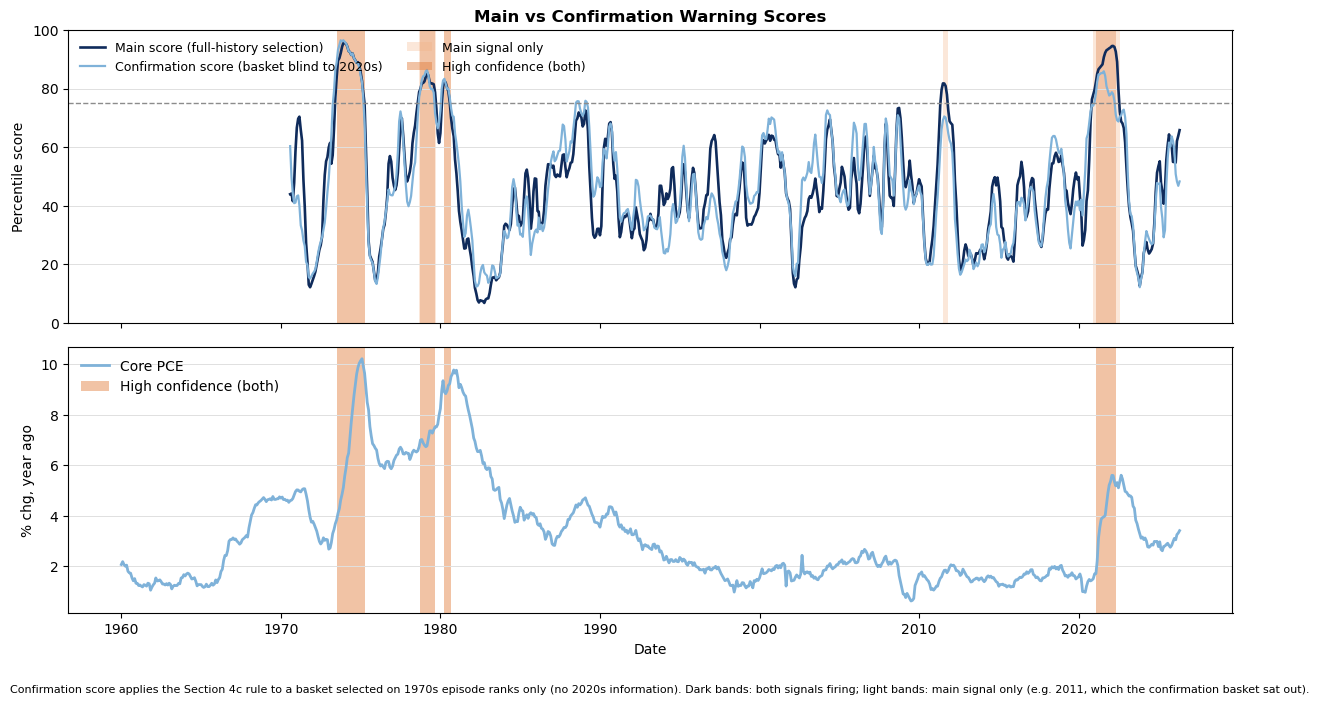

In [11]:
# ---------------- Exhibit 13f: main vs confirmation warning scores ----------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 7.2), sharex=True,
                               gridspec_kw={"height_ratios": [1.1, 1.0]})
ax1.plot(warning_score.index, warning_score, color=NAVY, lw=1.9,
         label="Main score (full-history selection)")
ax1.plot(confirmation_score.index, confirmation_score, color=LTBLUE, lw=1.6,
         label="Confirmation score (basket blind to 2020s)")
ax1.axhline(WARNING_SCORE_THRESHOLD, color="0.55", lw=1.0, ls="--")
shade_true_runs(ax1, main_only_signal, color="#f4b183", alpha=0.30, label="Main signal only")
shade_true_runs(ax1, high_confidence_signal, color="#e07b39", alpha=0.45,
                label="High confidence (both)")
ax1.set_ylim(0, 100)
ax1.set_ylabel("Percentile score")
ax1.set_title("Main vs Confirmation Warning Scores", fontweight="bold")
ax1.legend(loc="upper left", ncol=2, frameon=False, fontsize=9)
ax1.grid(axis="y", color="0.88", lw=0.7)

ax2.plot(core_yoy.index, core_yoy, color=LTBLUE, lw=2.0, label="Core PCE")
shade_true_runs(ax2, high_confidence_signal, color="#e07b39", alpha=0.45,
                label="High confidence (both)")
ax2.set_ylabel("% chg, year ago")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", frameon=False)
ax2.grid(axis="y", color="0.88", lw=0.7)

fig.text(0.01, 0.01,
         "Confirmation score applies the Section 4c rule to a basket selected on 1970s episode "
         "ranks only (no 2020s information). Dark bands: both signals firing; light bands: main "
         "signal only (e.g. 2011, which the confirmation basket sat out).",
         fontsize=8)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
fig.savefig(FIG_DIR / "exhibit13f_confirmation_score.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# ---------------- summary checks ----------------

def check(name, ok, detail=""):
    print(f"[{'PASS' if ok else 'WARN'}] {name}" + (f" - {detail}" if detail else ""))


check("1. selection scorer recovers a synthetic 6m lead", _lead == 6)
check("2. Tornqvist reconstruction tracks core PCE", RECON_CORR > 0.99, f"corr={RECON_CORR:.4f}")
check("3. main warning fires before every episode",
      all(pd.notna(v) and v > 0 for v in main_episode_leads),
      ", ".join(f"{i}: {v:+.0f}m" for i, v in main_episode_leads.items()))
check("4. main false alarms 1985-2019 at most 6 months",
      warning_false_alarms_8519 <= 6, f"{warning_false_alarms_8519} months")
check("5. main beats core-momentum baseline on false alarms",
      warning_false_alarms_8519 < baseline_false_alarms_8519,
      f"{warning_false_alarms_8519} vs {baseline_false_alarms_8519}")
check("6. high-confidence signal fires before every episode",
      all(pd.notna(v) and v > 0 for v in HC_EPISODE_LEADS),
      ", ".join(f"{i}: {v:+.0f}m" for i, v in HC_EPISODE_LEADS.items()))
check("7. high-confidence false alarms 1985-2019 at most 2 months",
      HC_FALSE_ALARMS_8519 <= 2, f"{HC_FALSE_ALARMS_8519} months")
check("8. cached run makes zero API calls (meaningful when REFRESH=False and cache exists)",
      HTTP_REQUESTS["count"] == 0 or REFRESH, f"{HTTP_REQUESTS['count']} requests")

[PASS] 1. selection scorer recovers a synthetic 6m lead
[PASS] 2. Tornqvist reconstruction tracks core PCE - corr=0.9973
[PASS] 3. main warning fires before every episode - 1973-75 acceleration: +1m, 1977-80 acceleration: +12m, 2021-22 acceleration: +4m
[PASS] 4. main false alarms 1985-2019 at most 6 months - 4 months
[PASS] 5. main beats core-momentum baseline on false alarms - 4 vs 38
[PASS] 6. high-confidence signal fires before every episode - 1973-75 acceleration: +1m, 1977-80 acceleration: +11m, 2021-22 acceleration: +2m
[PASS] 7. high-confidence false alarms 1985-2019 at most 2 months - 0 months
[PASS] 8. cached run makes zero API calls (meaningful when REFRESH=False and cache exists) - 0 requests
